In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
url = 'https://raw.githubusercontent.com/niksonlaurentino/SCTECH_Projeto_Avaliativo_M_1/fase/eda/dataset/credit_risk_dataset.csv'

In [25]:
df = pd.read_csv(url)

# Fase 1: Análise Exploratória de Dados (EDA)
# Descritiva e Estatística: tamanho total da base (linhas e colunas)

In [26]:
df.shape

(32581, 12)

# Tipos de dados de cada variável 

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


# Sumário estatístico descritivo (médias, mínimos, máximos e quartis via .describe())

In [28]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Utilizo o df.select_dtypes(include='str').columns para ver os elementos que são categóricos para poder ver os valores categóricos únicos com a iteração.

In [29]:
cat_cols = df.select_dtypes(include='str').columns

In [30]:
for column in cat_cols:
    print(f'Coluna: {df[column].value_counts()}')
    print(f'{50*'-'}')

Coluna: person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
--------------------------------------------------
Coluna: loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
--------------------------------------------------
Coluna: loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
--------------------------------------------------
Coluna: cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
--------------------------------------------------


# Análise Visual: 
# Histograma de distribuição de idades/valores

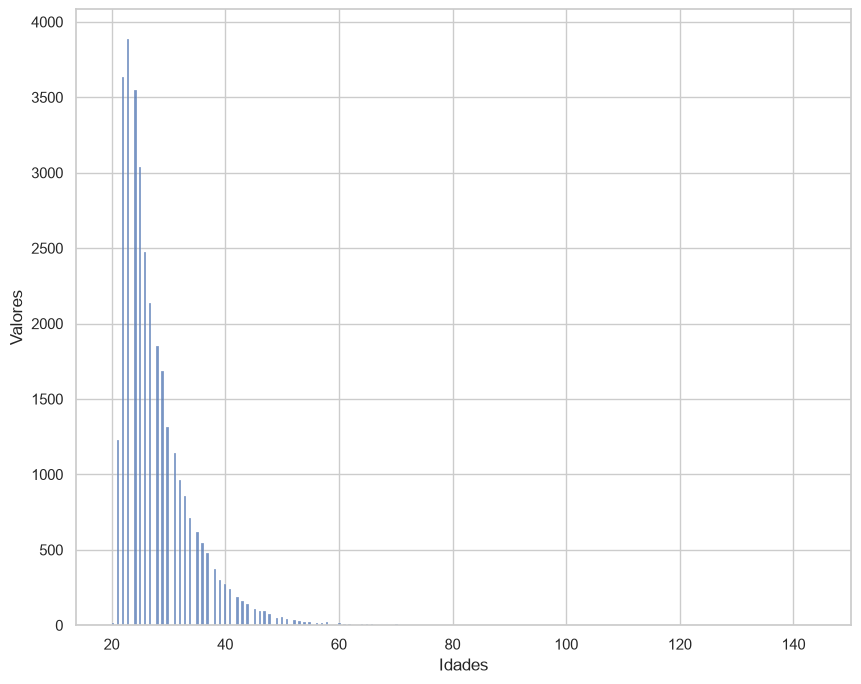

In [56]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=[10,8])
sns.histplot(df, x='person_age')
plt.ylabel('Valores')
plt.xlabel('Idades')
plt.show()

# Gráfico de barras provando o desbalanceamento da variável alvo 

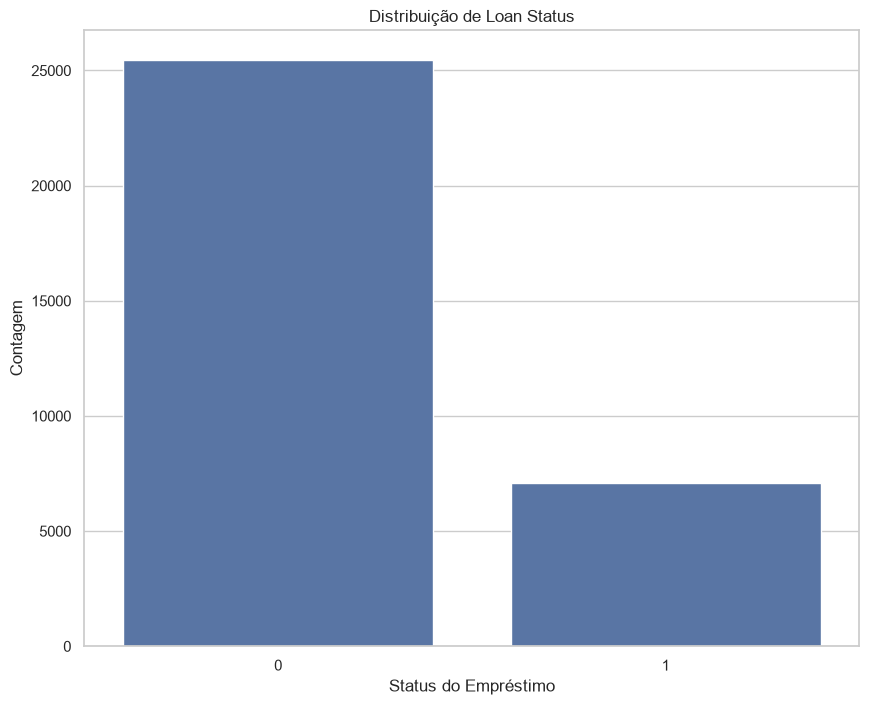

In [57]:
plt.figure(figsize=[10, 8])
sns.countplot(data=df, x='loan_status')
plt.title('Distribuição de Loan Status')
plt.xlabel('Status do Empréstimo')
plt.ylabel('Contagem')
plt.show()

# Mapa de calor de correlação de Pearson das variáveis numéricas

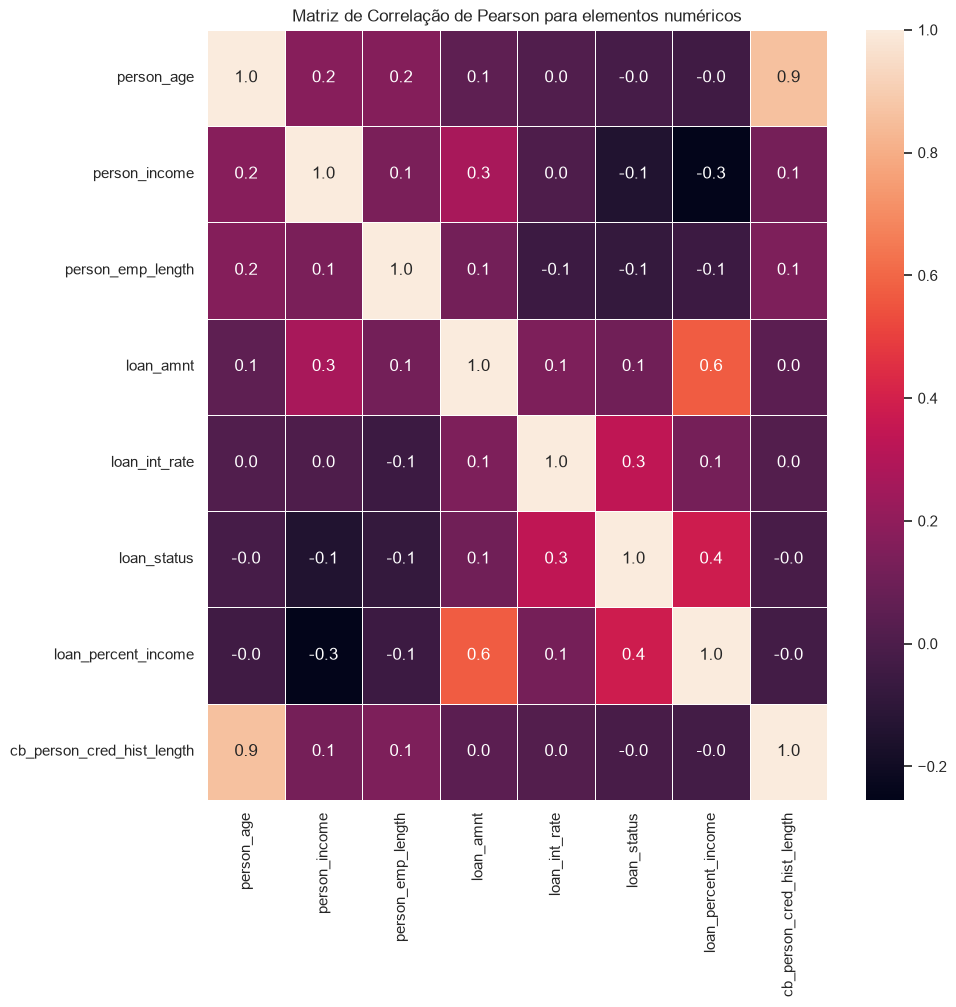

In [58]:
num_cols = df.select_dtypes(include='number')
plt.figure(figsize=[10,10])
sns.heatmap(num_cols.corr(), annot=True, fmt='.1f', linewidth=.5)
plt.title('Matriz de Correlação de Pearson para elementos numéricos')
plt.show()